In [15]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal
from pydantic import Field , BaseModel
from langchain_huggingface import ChatHuggingFace , HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser


In [3]:
load_dotenv()


True

In [ ]:
llm=HuggingFaceEndpoint(model='Qwen/Qwen3.6-27B',
                        task='text_generation')
model=ChatHuggingFace(llm=llm)


In [56]:
class SentimentSchema(BaseModel):
    sentiment:Literal['Positive', 'Negative']=Field(description='Sentiment of the Review')
    

In [57]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [64]:
structured_model=model.with_structured_output(SentimentSchema,
                                              method='json_schema')
structured_model2=model.with_structured_output(DiagnosisSchema,
                                               method='json_schema')



In [65]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal['Positive', 'Negative']
    diagnosis:dict
    response:str

In [66]:
def find_sentiment(state:ReviewState):
    prompt=f'For the following Review find out the sentiment in one word Postive or negative:\n {state['review']}'
    result=structured_model.invoke(prompt)['sentiment']
    return {'sentiment':result}

def check_sentiment(state:ReviewState)->Literal['positive_response', 'run_diagnosis']:
    if state['sentiment']=='Positive':
        return 'postive_response'
    else :
        return 'run_diagnosis'
    
def run_diagnosis(state:ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def positive_response(state:ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}


def negative_response(state:ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}


In [67]:
graph=StateGraph(ReviewState)

graph.add_node('find sentiment', find_sentiment)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('positive_response', positive_response)
graph.add_node('negative_response',negative_response)
    

graph.add_edge(START, 'find sentiment')
graph.add_conditional_edges('find sentiment', check_sentiment)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)
graph.add_edge('positive_response',END)

workflow=graph.compile()

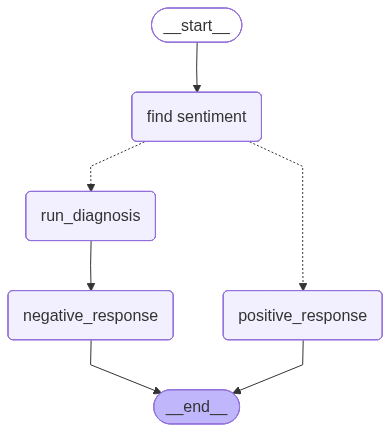

In [68]:
workflow

In [ ]:
inital_state={'review':"I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
final_state=workflow.invoke(inital_state)

In [ ]:
final_state

'Negative'